# L7d Lab: A Testable Housing-Price OLS Model

This compact instructor-authored example retains the 2025 housing-model structure while making data generation and validation deterministic.

> **Learning objectives**
>
> - Build a design matrix from interpretable engineering-style features.
> - Fit OLS and report coefficients with units.
> - Check residual orthogonality and prediction metrics.
> - Separate interpolation evidence from extrapolation claims.


## Setup


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


In [2]:
area = collect(range(800.0, 2400.0; length = 48))
bedrooms = Float64.([2 + (i % 4) for i in eachindex(area)])
age = Float64.([3 + (7i % 35) for i in eachindex(area)])
noise = Float64.([(-1)^i * (i % 5) * 2.5 for i in eachindex(area)])
price = 50.0 .+ 0.20 .* area .+ 15.0 .* bedrooms .- 0.50 .* age .+ noise
X = hcat(area, bedrooms, age)
fit = ols_fit(X, price)
report = regression_report(price, fit.predictions)
(coefficients = fit.coefficients, report = report)


(coefficients = [57.47580521184847, 0.200292593503937, 12.674212598425203, -0.4761979752530936], report = (rmse = 5.482507925573918, mae = 4.572769028871396, r2 = 0.9967088949372219, sse = 1442.7788713910795))

In [3]:
coefficient_table = DataFrame(
    term = ["intercept (k\$)", "area (k\$/ft²)", "bedroom (k\$)", "age (k\$/year)"],
    estimate = fit.coefficients,
)
pretty_table(coefficient_table)


┌────────────────┬───────────┐
│           term │  estimate │
│         String │   Float64 │
├────────────────┼───────────┤
│ intercept (k$) │   57.4758 │
│  area (k$/ft²) │  0.200293 │
│   bedroom (k$) │   12.6742 │
│  age (k$/year) │ -0.476198 │
└────────────────┴───────────┘


In [4]:
@test report.r2 > 0.99
@test norm(transpose(fit.design) * fit.residuals) < 1e-8
@test report.rmse < 8.0
:housing_ols_verified


:housing_ols_verified

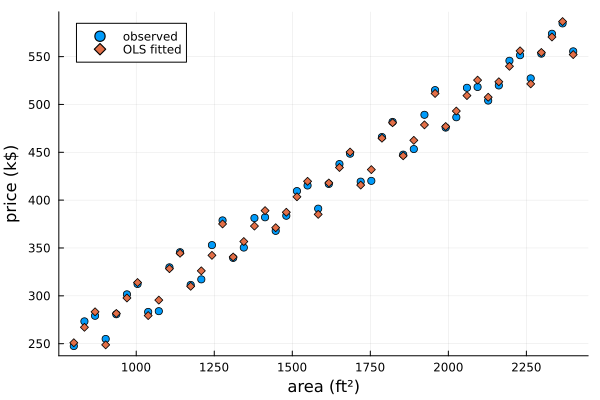

In [5]:
scatter(area, price; label = "observed", xlabel = "area (ft²)", ylabel = "price (k\$)")
scatter!(area, fit.predictions; label = "OLS fitted", marker = :diamond)


## Summary

The fit recovers the known synthetic signal and satisfies the least-squares orthogonality condition. That validates the implementation—not a real housing-market claim. Real use would require provenance, train/test separation, nonlinear checks, and attention to correlated features.
